# 04 · Parametrik Olmayan Testler (Nonparametric Tests)
**Statistical Inference Lab**

---
> **Bu notebook'ta ne öğreneceğiz?**  
> 01'de t-test'i, 03'te ise regresyon hatalarının **Normal dağılması gerektiğini** öğrendik —
> ve 03'te gerçek Auto MPG verisinde bu varsayımın **ihlal edildiğini** bizzat gördük
> (Shapiro-Wilk p≈0.000001). Peki normallik varsayımı sağlanmıyorsa ne yaparsın? Bu notebook'ta
> **rank-tabanlı (sıralama temelli)** testleri öğreneceğiz — bunlar hiçbir dağılım varsayımı
> yapmadan, verinin ham değerleri yerine **sıralamasını** kullanarak aynı soruları cevaplıyor.

**Önkoşul:** Hipotez Testi (01), Regresyon Tanılama (03 — normallik ihlali örneği),
Spearman Korelasyonu (`probability-lab` 04b)  
**Veri:**  
- `winequality-red.csv` — 1599 kırmızı şarap (kalite skoru, kimyasal özellikler)  
- `Absenteeism_at_work.csv` — 740 çalışan kaydı (devamsızlık saatleri, aşırı çarpık)  
**Araçlar:** Python (scipy.stats), R (base R `wilcox.test`, `kruskal.test`)

---
## 1 · Ne Zaman Parametrik Varsayımlar Bozulur?

t-test, ANOVA gibi "parametrik" testler, verinin (veya hata teriminin) **Normal dağıldığını**
varsayıyor. Bu varsayım şu durumlarda sıkça bozulur:

- **Aşırı çarpık veri** (bu notebook'taki `Absenteeism time in hours` gibi — çoğu kişi 0-3 saat,
  birkaçı 120 saat)
- **Küçük örneklem + bilinmeyen dağılım** (normalliği test edecek kadar bile veri yok)
- **Ordinal veri** (şarap kalitesi gibi 3-8 arası sıralı ama "eşit aralıklı" olmayan skorlar)
- **Aykırı değerlerin (outlier) çok etkili olduğu veri** (03'teki normallik ihlali örneğini hatırla)

Bu durumlarda t-test'e "zorla" güvenmek, 03'te gördüğümüz gibi **yanıltıcı p-value ve güven
aralıklarına** yol açabilir.

---
## 2 · Rank-Tabanlı Testlerin Mantığı: Sayılar Yerine Sıralama

Nonparametrik testlerin ortak sırrı basit: **ham değerler yerine, değerlerin sıralamasını
(rank) kullanmak.** Bu, `probability-lab` 04b'deki **Spearman korelasyonuyla birebir aynı
felsefe** — Spearman da Pearson'ın "ham değer" yaklaşımı yerine "sıralama" yaklaşımını
kullanıyordu, aynı mantık burada hipotez testine uygulanıyor.

**Neden işe yarıyor?** Sıralama işlemi, aşırı değerlerin (outlier) etkisini otomatik olarak
sınırlıyor — en büyük değer ister 10 olsun ister 10.000, sıralamada hep "en büyük" (son
sıra) olarak kalıyor. Bu, testi aşırı değerlere karşı **dayanıklı (robust)** yapıyor.

---
## 3 · Parametrik ↔ Nonparametrik Eşleştirme Tablosu

| Parametrik Test | Nonparametrik Karşılığı | Ne Zaman Kullanılır |
|---|---|---|
| Bağımsız İki Örneklemli t-test | **Mann-Whitney U** | İki bağımsız grubu karşılaştırma |
| Eşleştirilmiş (Paired) t-test | **Wilcoxon Signed-Rank** | Aynı birimlerin öncesi/sonrası karşılaştırması |
| One-way ANOVA | **Kruskal-Wallis** | 3+ bağımsız grubu karşılaştırma |

Üçünü de bu notebook'ta işleyeceğiz — her birini önce **mantığıyla**, sonra **gerçek veriyle**.

---
## 4 · Mann-Whitney U Testinin Mekaniği (Adım Adım)

Somut bir örnekle gidelim: Grup A = $[3, 7, 9]$, Grup B = $[5, 6, 11]$.

**Adım 1 — Tüm veriyi birleştirip sırala, rank ver:**

| Değer | 3 | 5 | 6 | 7 | 9 | 11 |
|---|---|---|---|---|---|---|
| Grup | A | B | B | A | A | B |
| Rank | 1 | 2 | 3 | 4 | 5 | 6 |

(Eşit değerler varsa — "tie" — onlara ortalama rank verilir, örn. iki tane 5 varsa ikisi de rank 2.5 alır.)

**Adım 2 — Her grubun rank TOPLAMINI hesapla:**
$$R_A = 1+4+5 = 10 \qquad R_B = 2+3+6 = 11$$

**Adım 3 — U formülünü uygula:**
$$U_A = R_A - \frac{n_A(n_A+1)}{2} = 10 - \frac{3\times 4}{2} = 10 - 6 = 4$$
$$U_B = R_B - \frac{n_B(n_B+1)}{2} = 11 - 6 = 5$$

**Adım 4 — Test istatistiği:** $U = \min(U_A, U_B) = 4$

**Sezgisi:** $U$, aslında "A grubundan bir değer alıp B grubundan bir değerle karşılaştırdığında,
A'nın B'den kaç kez BÜYÜK çıktığını" sayıyor (tüm ikili kombinasyonlar üzerinden). $U$ küçükse,
gruplardan biri sistematik olarak diğerinden küçük demektir — yani gruplar farklı.
$U_A + U_B = n_A \times n_B$ her zaman sağlanır (kontrol: $4+5=9=3\times 3$ ✓) — bu, hesabını
doğrulamak için kullanabileceğin bir "sağlama" kuralı.

In [1]:
import scipy.stats as stats

A = [3, 7, 9]
B = [5, 6, 11]

# Elle hesapladigimizi scipy ile dogrulayalim
u_stat, p_deger = stats.mannwhitneyu(A, B, alternative='two-sided')
print(f"scipy'nin bulduğu U: {u_stat}")
print(f"Elle hesapladığımız U: 4")
print(f"Örtüşüyor mü? {'EVET ✓' if u_stat == 4 else 'HAYIR'}")

scipy'nin bulduğu U: 4.0
Elle hesapladığımız U: 4
Örtüşüyor mü? EVET ✓


---
## 5 · Wilcoxon Signed-Rank Testinin Mekaniği (Adım Adım)

5 eşleştirilmiş gözlem için farkları ($d_i = \text{sonrası} - \text{öncesi}$) hesapladığımızı
varsayalım: $d = [-2, 3, -1, 5, -4]$.

**Adım 1 — Sıfır farkları at (varsa), MUTLAK DEĞERLERİNİ ALARAK sırala ve rank ver:**

| $\|d_i\|$ | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| Orijinal $d_i$ | $-1$ | $-2$ | $3$ | $-4$ | $5$ |
| Rank | 1 | 2 | 3 | 4 | 5 |

**Adım 2 — Rank'lere orijinal işareti geri ver, pozitif ve negatif rankları ayrı ayrı topla:**
$$W^+ = \underbrace{3}_{d=3} + \underbrace{5}_{d=5} = 8 \qquad W^- = \underbrace{1}_{d=-1} + \underbrace{2}_{d=-2} + \underbrace{4}_{d=-4} = 7$$

**Adım 3 — Test istatistiği:** $W = \min(W^+, W^-) = 7$

**Sezgisi:** Eğer öncesi/sonrası arasında GERÇEKTEN bir fark yoksa, pozitif ve negatif
farkların büyüklüğü (rankı) yaklaşık eşit dağılmalı — yani $W^+ \approx W^-$. Biri
diğerinden çok büyükse (örn. $W^+ \gg W^-$), sistematik bir yönde (hep artış ya da hep
azalış) bir fark var demektir. Sağlama kuralı: $W^+ + W^- = \frac{n(n+1)}{2}$
(kontrol: $8+7=15=\frac{5\times 6}{2}$ ✓).

In [2]:
oncesi_ornek = [10, 10, 10, 10, 10]
sonrasi_ornek = [8, 13, 9, 15, 6]  # d = [-2, 3, -1, 5, -4]

w_stat, p_deger_w = stats.wilcoxon(sonrasi_ornek, oncesi_ornek)
print(f"scipy'nin bulduğu W: {w_stat}")
print(f"Elle hesapladığımız W: 7")
print(f"Örtüşüyor mü? {'EVET ✓' if w_stat == 7 else 'HAYIR'}")

scipy'nin bulduğu W: 7.0
Elle hesapladığımız W: 7
Örtüşüyor mü? EVET ✓


---
## 6 · Kruskal-Wallis Testinin Mekaniği (Adım Adım)

3 grup, her biri 3 gözlem: Grup1=$[1,2,3]$, Grup2=$[4,5,6]$, Grup3=$[7,8,9]$ (kasıtlı olarak
tamamen ayrışmış veri seçtik, ki formülün "en güçlü" halini görebilelim).

**Adım 1 — TÜM veriyi (gruplar karışık) sırala, rank ver.** Bu örnekte rakamlar zaten
sıralı olduğu için rank = değerin kendisi: Grup1 → rank $\{1,2,3\}$, Grup2 → rank
$\{4,5,6\}$, Grup3 → rank $\{7,8,9\}$.

**Adım 2 — Her grubun rank toplamını hesapla:**
$$R_1 = 1+2+3=6 \qquad R_2=4+5+6=15 \qquad R_3=7+8+9=24$$

**Adım 3 — H formülünü uygula** ($N$=toplam gözlem sayısı, $n_i$=grup $i$'nin büyüklüğü):
$$H = \frac{12}{N(N+1)}\sum_{i} \frac{R_i^2}{n_i} - 3(N+1)$$
$$H = \frac{12}{9\times 10}\left(\frac{6^2}{3}+\frac{15^2}{3}+\frac{24^2}{3}\right) - 3\times 10$$
$$H = 0.1333\times(12+75+192) - 30 = 37.2 - 30 = 7.2$$

**Sezgisi:** Bu formül aslında **ANOVA'nın F-istatistiğiyle birebir aynı mantıkta** —
"gruplar arası rank farkı" ile "toplam rank değişkenliği" oranlanıyor (05'teki Law of Total
Variance'ın rank versiyonu). $H$ büyükse, gruplar arası fark, rastgele gürültüden çok daha
büyük demektir. $H$, yaklaşık olarak Ki-Kare dağılımına uyar (serbestlik derecesi = grup
sayısı $-1$).

In [3]:
g1, g2, g3 = [1,2,3], [4,5,6], [7,8,9]

h_stat, p_deger_h = stats.kruskal(g1, g2, g3)
print(f"scipy'nin bulduğu H: {h_stat:.4f}")
print(f"Elle hesapladığımız H: 7.2")
print(f"Örtüşüyor mü? {'EVET ✓' if abs(h_stat - 7.2) < 1e-9 else 'HAYIR'}")

scipy'nin bulduğu H: 7.2000
Elle hesapladığımız H: 7.2
Örtüşüyor mü? EVET ✓


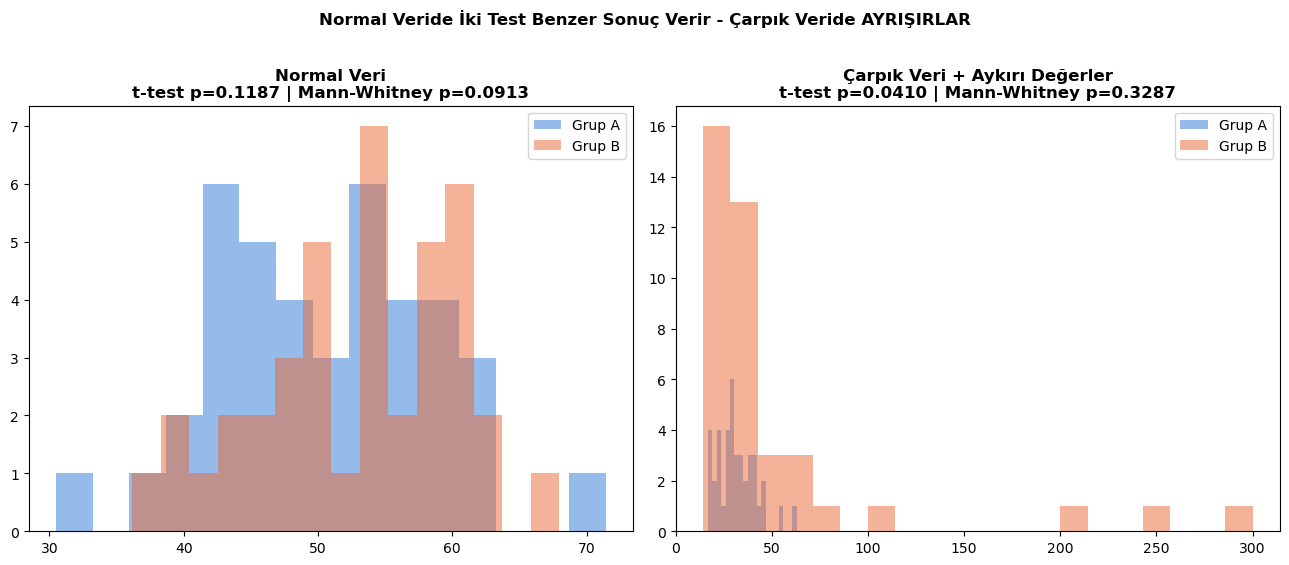

YORUM: Normal veride t-test ve Mann-Whitney neredeyse aynı p-değerini veriyor.
Çarpık veride ise birkaç aşırı değer t-test'in p-değerini büyük ölçüde ETKİLİYOR
(çünkü t-test ortalamaya dayanıyor, ortalama aykırı değerlere çok duyarlı) - ama
Mann-Whitney sıralamaya dayandığı için çok daha DAYANIKLI kalıyor.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

rng = np.random.default_rng(42)

# Senaryo: iki grup, biri normal biri COK carpik (log-normal + birkac asiri deger)
grup_normal_A = rng.normal(50, 10, 40)
grup_normal_B = rng.normal(53, 10, 40)  # hafif kaydirilmis, gercek kucuk bir fark var

grup_carpik_A = rng.lognormal(3.5, 0.4, 40)
grup_carpik_B = np.concatenate([rng.lognormal(3.5, 0.4, 37), [200, 250, 300]])  # birkac asiri deger eklendi

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].hist(grup_normal_A, bins=15, alpha=0.5, color='#2a78d6', label='Grup A')
axes[0].hist(grup_normal_B, bins=15, alpha=0.5, color='#eb6834', label='Grup B')
t_n, p_t_n = stats.ttest_ind(grup_normal_A, grup_normal_B)
u_n, p_u_n = stats.mannwhitneyu(grup_normal_A, grup_normal_B)
axes[0].set_title(f'Normal Veri\nt-test p={p_t_n:.4f} | Mann-Whitney p={p_u_n:.4f}', fontweight='bold')
axes[0].legend()

axes[1].hist(grup_carpik_A, bins=20, alpha=0.5, color='#2a78d6', label='Grup A')
axes[1].hist(grup_carpik_B, bins=20, alpha=0.5, color='#eb6834', label='Grup B')
t_c, p_t_c = stats.ttest_ind(grup_carpik_A, grup_carpik_B)
u_c, p_u_c = stats.mannwhitneyu(grup_carpik_A, grup_carpik_B)
axes[1].set_title(f'Çarpık Veri + Aykırı Değerler\nt-test p={p_t_c:.4f} | Mann-Whitney p={p_u_c:.4f}', fontweight='bold')
axes[1].legend()

plt.suptitle('Normal Veride İki Test Benzer Sonuç Verir - Çarpık Veride AYRIŞIRLAR', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("YORUM: Normal veride t-test ve Mann-Whitney neredeyse aynı p-değerini veriyor.")
print("Çarpık veride ise birkaç aşırı değer t-test'in p-değerini büyük ölçüde ETKİLİYOR")
print("(çünkü t-test ortalamaya dayanıyor, ortalama aykırı değerlere çok duyarlı) - ama")
print("Mann-Whitney sıralamaya dayandığı için çok daha DAYANIKLI kalıyor.")

---
# 🐍 Python Uygulaması

3 adımda ilerleyeceğiz:
1. **Mann-Whitney U** — Kaliteli/kalitesiz şaraplarda alkol seviyesi farkı
2. **Wilcoxon Signed-Rank** — Eşleştirilmiş (öncesi/sonrası) bir senaryo
3. **Kruskal-Wallis** — Mevsimlere göre devamsızlık saatleri (+ 05'e köprü: post-hoc çoklu karşılaştırma)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🍷 Python 1 — Mann-Whitney U: Kaliteli Şaraplarda Alkol Seviyesi Daha mı Yüksek?

**Ne yapıyoruz?**  
Şarapları `quality >= 7` (iyi) ve `quality < 7` (orta/kötü) olarak ikiye ayırıp, `alcohol`
seviyelerini karşılaştırıyoruz. Hem t-test hem Mann-Whitney uygulayıp sonuçları karşılaştıracağız.

Veri: 1599 şarap
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

İyi şaraplar (quality≥7): n=217, medyan alkol=11.60
Orta/kötü şaraplar (quality<7): n=1382, medyan alkol=10.00

Shapiro-Wilk (iyi grubu): p=0.232244
Shapiro-Wilk (orta/kötü grubu): p=0.000000
İkisi de normallikten anlamlı şekilde sapıyor - nonparametrik test daha güvenli bir seçim.

[Parametrik]    Welch t-test: t=17.4505, p=7.79e-47
[Nonparametrik] Mann-Whitney: U=246660.0, p=6.84e-53

İki test de aynı yönde ve anlamlı sonuç veriyor (büyük örneklem + orta düzey
çarpıklıkta bu beklenir) - ama Mann-Whitney'in varsayım gerektirmediğini unutma.


/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_10605/1750721125.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([orta_kotu, iyi], labels=['Orta/Kötü (quality<7)', 'İyi (quality≥7)'])


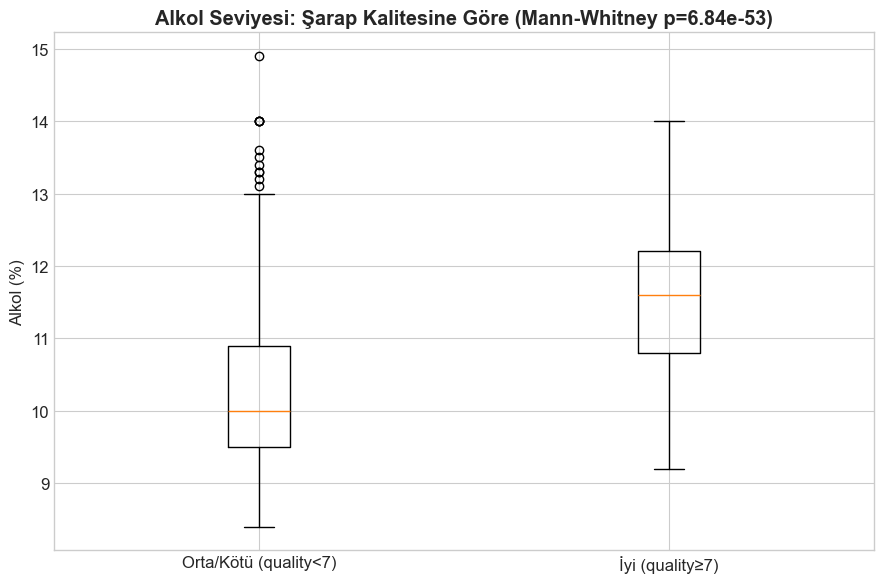

In [6]:
wine = pd.read_csv('data/winequality-red.csv')
print(f"Veri: {wine.shape[0]} şarap")
print(wine['quality'].value_counts().sort_index())

iyi = wine[wine['quality'] >= 7]['alcohol']
orta_kotu = wine[wine['quality'] < 7]['alcohol']

print(f"\nİyi şaraplar (quality≥7): n={len(iyi)}, medyan alkol={iyi.median():.2f}")
print(f"Orta/kötü şaraplar (quality<7): n={len(orta_kotu)}, medyan alkol={orta_kotu.median():.2f}")

# Once normallik kontrolu (03'teki gibi)
_, p_shapiro_iyi = stats.shapiro(iyi)
_, p_shapiro_kotu = stats.shapiro(orta_kotu)
print(f"\nShapiro-Wilk (iyi grubu): p={p_shapiro_iyi:.6f}")
print(f"Shapiro-Wilk (orta/kötü grubu): p={p_shapiro_kotu:.6f}")
print("İkisi de normallikten anlamlı şekilde sapıyor - nonparametrik test daha güvenli bir seçim.")

# t-test VE Mann-Whitney - ikisini de gosterelim
t_ist, p_t = stats.ttest_ind(iyi, orta_kotu, equal_var=False)
u_ist, p_u = stats.mannwhitneyu(iyi, orta_kotu, alternative='two-sided')

print(f"\n[Parametrik]    Welch t-test: t={t_ist:.4f}, p={p_t:.2e}")
print(f"[Nonparametrik] Mann-Whitney: U={u_ist:.1f}, p={p_u:.2e}")
print("\nİki test de aynı yönde ve anlamlı sonuç veriyor (büyük örneklem + orta düzey")
print("çarpıklıkta bu beklenir) - ama Mann-Whitney'in varsayım gerektirmediğini unutma.")

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot([orta_kotu, iyi], labels=['Orta/Kötü (quality<7)', 'İyi (quality≥7)'])
ax.set_ylabel('Alkol (%)')
ax.set_title(f'Alkol Seviyesi: Şarap Kalitesine Göre (Mann-Whitney p={p_u:.2e})', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 💊 Python 2 — Wilcoxon Signed-Rank: Eşleştirilmiş Veri (Sentetik Senaryo)

**Ne yapıyoruz?**  
Gerçek veri setlerimizde doğal bir "öncesi/sonrası" eşleştirilmiş yapı yok, bu yüzden burada
**açıkça etiketlenmiş sentetik** bir senaryo kullanıyoruz: 12 çalışana bir "stres azaltma
programı" öncesi ve sonrası bir anket uygulanmış (skorlar çarpık — çoğu kişi hafif değişim,
birkaçı büyük değişim gösteriyor).

Öncesi: [42 38 51 45 60 39 48 55 41 47 52 44]
Sonrası: [37.8 31.8 47.6 39.6 58.8 18.7 47.9 38.1 37.5 45.2 48.8 42.1]

Ortalama fark (Sonrası - Öncesi): -5.67

[YANLIŞ] Bağımsız t-test: t=-1.6314, p=0.1170
[Parametrik]    Eşleştirilmiş t-test: t=-3.1114, p=0.0099
[Nonparametrik] Wilcoxon Signed-Rank: W=0.0, p=0.0005

YORUM: n=12 gibi küçük bir örneklemde normallik varsayımını güvenle test edemezsin
(Shapiro-Wilk küçük n'de zaten düşük güce sahip) - bu yüzden küçük örneklemli eşleştirilmiş
verilerde Wilcoxon, t-test'e göre daha güvenli bir VARSAYILAN seçim olabilir.


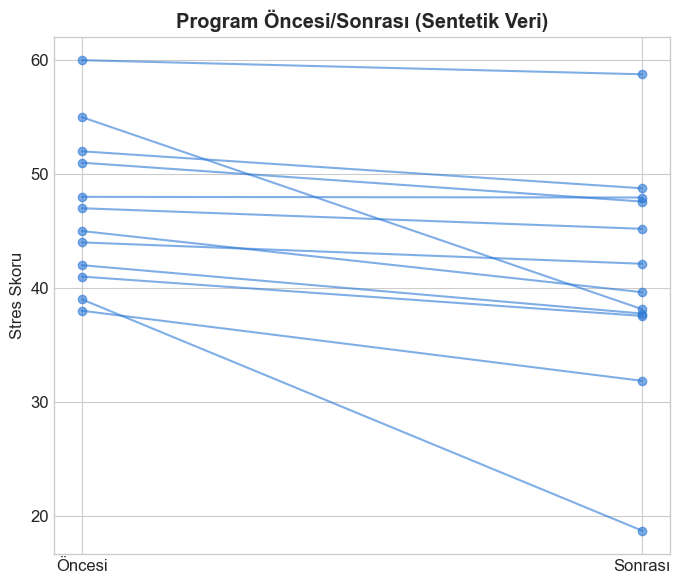

In [7]:
# SENTETIK VERI - net sekilde boyle etiketliyoruz
rng = np.random.default_rng(7)
oncesi = np.array([42, 38, 51, 45, 60, 39, 48, 55, 41, 47, 52, 44])
sonrasi = oncesi - rng.exponential(scale=6, size=12)  # cogunlukla iyilesme, carpik bir etki

print("Öncesi:", oncesi)
print("Sonrası:", np.round(sonrasi, 1))
print(f"\nOrtalama fark (Sonrası - Öncesi): {(sonrasi - oncesi).mean():.2f}")

# ===== YANLIS: bagimsiz gruplar gibi test etmek =====
t_bagimsiz, p_bagimsiz = stats.ttest_ind(sonrasi, oncesi)
print(f"\n[YANLIŞ] Bağımsız t-test: t={t_bagimsiz:.4f}, p={p_bagimsiz:.4f}")

# ===== DOGRU: eslestirilmis =====
t_paired, p_paired = stats.ttest_rel(sonrasi, oncesi)
print(f"[Parametrik]    Eşleştirilmiş t-test: t={t_paired:.4f}, p={p_paired:.4f}")

w_ist, p_wilcoxon = stats.wilcoxon(sonrasi, oncesi)
print(f"[Nonparametrik] Wilcoxon Signed-Rank: W={w_ist:.1f}, p={p_wilcoxon:.4f}")

print("\nYORUM: n=12 gibi küçük bir örneklemde normallik varsayımını güvenle test edemezsin")
print("(Shapiro-Wilk küçük n'de zaten düşük güce sahip) - bu yüzden küçük örneklemli eşleştirilmiş")
print("verilerde Wilcoxon, t-test'e göre daha güvenli bir VARSAYILAN seçim olabilir.")

fig, ax = plt.subplots(figsize=(7, 6))
for i in range(len(oncesi)):
    ax.plot([1, 2], [oncesi[i], sonrasi[i]], 'o-', color='#2a78d6', alpha=0.6)
ax.set_xticks([1, 2]); ax.set_xticklabels(['Öncesi', 'Sonrası'])
ax.set_ylabel('Stres Skoru')
ax.set_title('Program Öncesi/Sonrası (Sentetik Veri)', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 📅 Python 3 — Kruskal-Wallis: Mevsimlere Göre Devamsızlık

**Ne yapıyoruz?**  
`Absenteeism_at_work.csv`'de 4 mevsim arasında devamsızlık saatlerini karşılaştırıyoruz.
Veri aşırı çarpık olduğu için (birkaç kişi 100+ saat devamsız) ANOVA yerine Kruskal-Wallis
kullanıyoruz — ayrıca "hangi mevsimler birbirinden farklı" sorusunu 05'teki (Multiple Testing)
Bonferroni düzeltmesiyle post-hoc olarak cevaplayacağız (küçük bir önizleme).

Veri: 740 kayıt
Yaz: n=170, medyan=4.0, ortalama=7.30, max=120
Sonbahar: n=192, medyan=3.0, ortalama=6.00, max=112
Kış: n=183, medyan=4.0, ortalama=8.15, max=120
İlkbahar: n=195, medyan=3.0, ortalama=6.35, max=120

Kruskal-Wallis: H=7.8033, p=0.0503
H0 reddedilemedi - mevsimler arasında anlamlı fark bulunamadı.


/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_10605/362868016.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(gruplar, labels=[mevsim_isimleri[s] for s in [1,2,3,4]], showfliers=True)


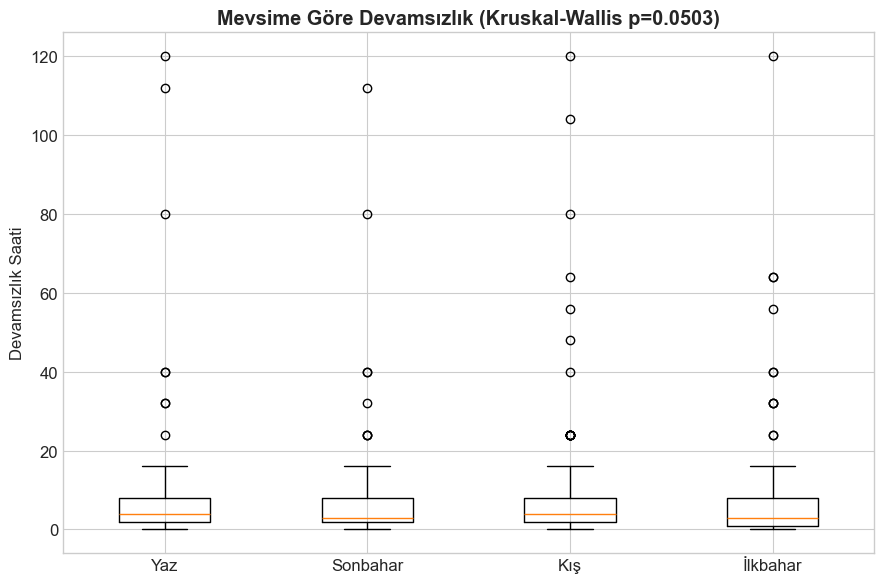


NOT: Bu post-hoc yaklaşım 05'te (Multiple Testing) çok daha detaylı işlenecek -
burada sadece 'çoklu ikili karşılaştırma yaparken düzeltme gerekir' fikrini önizledik.


In [8]:
absenteeism = pd.read_csv('data/Absenteeism_at_work.csv', sep=';')
print(f"Veri: {absenteeism.shape[0]} kayıt")

mevsim_isimleri = {1: 'Yaz', 2: 'Sonbahar', 3: 'Kış', 4: 'İlkbahar'}  # veri setinin dokümantasyonuna göre
absenteeism['Mevsim'] = absenteeism['Seasons'].map(mevsim_isimleri)

gruplar = [absenteeism[absenteeism['Seasons'] == s]['Absenteeism time in hours'].values for s in [1, 2, 3, 4]]
for s, isim in mevsim_isimleri.items():
    veri = absenteeism[absenteeism['Seasons'] == s]['Absenteeism time in hours']
    print(f"{isim}: n={len(veri)}, medyan={veri.median():.1f}, ortalama={veri.mean():.2f}, max={veri.max()}")

# Kruskal-Wallis
h_ist, p_kw = stats.kruskal(*gruplar)
print(f"\nKruskal-Wallis: H={h_ist:.4f}, p={p_kw:.4f}")

if p_kw < 0.05:
    print("H0 reddedildi - en az bir mevsim diğerlerinden anlamlı şekilde farklı.")
    print("\n--- Post-hoc: İkili Mann-Whitney Karşılaştırmaları (Bonferroni düzeltmeli) ---")
    from itertools import combinations
    ikili_karsilastirmalar = list(combinations([1, 2, 3, 4], 2))
    alpha_orijinal = 0.05
    alpha_duzeltilmis = alpha_orijinal / len(ikili_karsilastirmalar)  # Bonferroni - 05'e onizleme
    print(f"Bonferroni düzeltilmiş α: {alpha_orijinal}/{len(ikili_karsilastirmalar)} = {alpha_duzeltilmis:.4f}")

    for s1, s2 in ikili_karsilastirmalar:
        grup1 = absenteeism[absenteeism['Seasons'] == s1]['Absenteeism time in hours']
        grup2 = absenteeism[absenteeism['Seasons'] == s2]['Absenteeism time in hours']
        _, p_ikili = stats.mannwhitneyu(grup1, grup2)
        anlamli = "✓ ANLAMLI (düzeltilmiş eşiğe göre)" if p_ikili < alpha_duzeltilmis else ""
        print(f"{mevsim_isimleri[s1]} vs {mevsim_isimleri[s2]}: p={p_ikili:.4f} {anlamli}")
else:
    print("H0 reddedilemedi - mevsimler arasında anlamlı fark bulunamadı.")

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(gruplar, labels=[mevsim_isimleri[s] for s in [1,2,3,4]], showfliers=True)
ax.set_ylabel('Devamsızlık Saati')
ax.set_title(f'Mevsime Göre Devamsızlık (Kruskal-Wallis p={p_kw:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNOT: Bu post-hoc yaklaşım 05'te (Multiple Testing) çok daha detaylı işlenecek -")
print("burada sadece 'çoklu ikili karşılaştırma yaparken düzeltme gerekir' fikrini önizledik.")

---
# 📊 R Uygulaması

R'ın `wilcox.test()` fonksiyonu hem Mann-Whitney'i hem Wilcoxon Signed-Rank'i tek fonksiyonda
topluyor (`paired=TRUE/FALSE` argümanıyla) — 01'deki `t.test()` deneyimine çok benzer bir kalıp.

In [9]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🍷 R 1 — Mann-Whitney U (`wilcox.test`, `paired=FALSE`)

**Yeni R kavramı yok** — `t.test()` deneyiminden tanıdık formül arayüzü.


	Wilcoxon rank sum test with continuity correction

data:  alcohol by grup
W = 246660, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



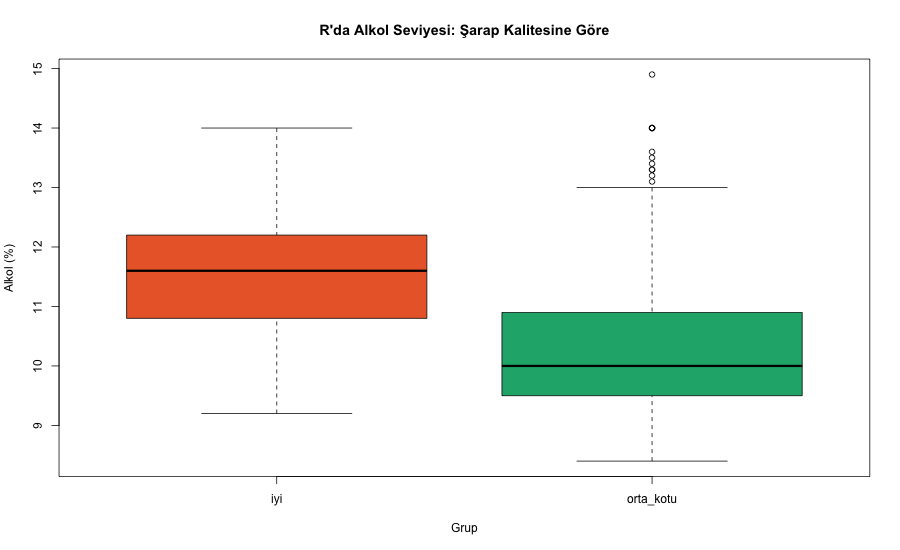

In [10]:
%%R -i wine -w 900 -h 550

colnames(wine) <- gsub(" ", "_", colnames(wine))
wine$grup <- ifelse(wine$quality >= 7, "iyi", "orta_kotu")

sonuc_mw <- wilcox.test(alcohol ~ grup, data = wine)
print(sonuc_mw)

boxplot(alcohol ~ grup, data = wine, col = c("#eb6834", "#1baf7a"),
        main = "R'da Alkol Seviyesi: Şarap Kalitesine Göre", xlab = "Grup", ylab = "Alkol (%)")

---
### 💊 R 2 — Wilcoxon Signed-Rank (`wilcox.test`, `paired=TRUE`)

**Yeni R kavramı yok** — aynı fonksiyon, sadece `paired=TRUE` argümanı ekleniyor.


	Wilcoxon signed rank exact test

data:  sonrasi and oncesi
V = 0, p-value = 0.0004883
alternative hypothesis: true location shift is not equal to 0


Python'daki p-değeriyle karşılaştır - birebir örtüşmeli.


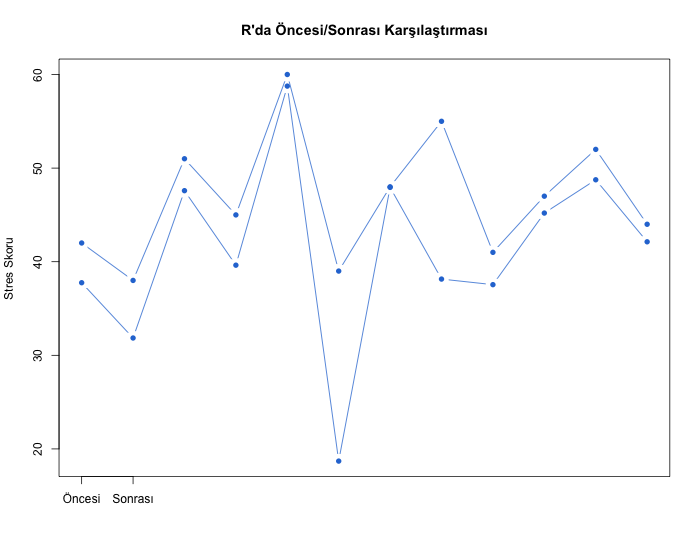

In [11]:
%%R -i oncesi -i sonrasi -w 700 -h 550

sonuc_wilcoxon <- wilcox.test(sonrasi, oncesi, paired = TRUE)
print(sonuc_wilcoxon)

cat("\nPython'daki p-değeriyle karşılaştır - birebir örtüşmeli.\n")

matplot(t(rbind(oncesi, sonrasi)), type = "b", pch = 16, col = "#2a78d6", lty = 1,
        xaxt = "n", xlab = "", ylab = "Stres Skoru", main = "R'da Öncesi/Sonrası Karşılaştırması")
axis(1, at = 1:2, labels = c("Öncesi", "Sonrası"))

---
### 📅 R 3 — Kruskal-Wallis

**Yeni R kavramı yok** — `kruskal.test(y ~ grup, data)`, `t.test()`/`wilcox.test()` ile
aynı formül mantığı, artık 3. kez gördüğün bir kalıp.


	Kruskal-Wallis rank sum test

data:  Absenteeism_time_in_hours by Seasons
Kruskal-Wallis chi-squared = 7.8033, df = 3, p-value = 0.05026



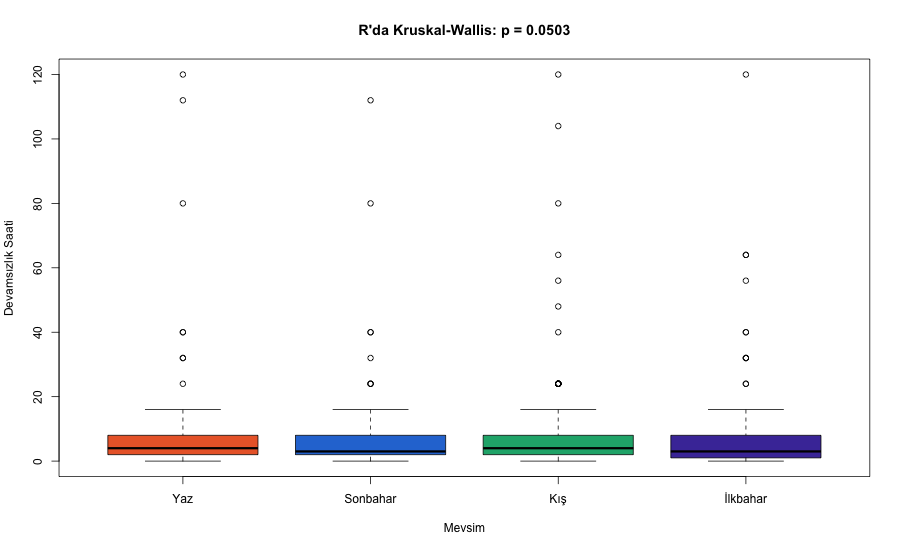

In [12]:
%%R -i absenteeism -w 900 -h 550

colnames(absenteeism) <- gsub(" ", "_", colnames(absenteeism))
absenteeism$Seasons <- as.factor(absenteeism$Seasons)

sonuc_kw <- kruskal.test(Absenteeism_time_in_hours ~ Seasons, data = absenteeism)
print(sonuc_kw)

boxplot(Absenteeism_time_in_hours ~ Seasons, data = absenteeism,
        col = c("#eb6834", "#2a78d6", "#1baf7a", "#4a3aa7"),
        names = c("Yaz", "Sonbahar", "Kış", "İlkbahar"),
        main = paste("R'da Kruskal-Wallis: p =", round(sonuc_kw$p.value, 4)),
        xlab = "Mevsim", ylab = "Devamsızlık Saati")

---
## ✏️ Egzersizler

---

### **E1 (Python).**
`winequality-red.csv`'de `volatile acidity` (uçucu asitlik) için medyan
üstü/altı iki grup oluştur, bu iki grubun `quality` skorunu Mann-Whitney ile karşılaştır.
Yüksek uçucu asitlik, düşük kaliteyle ilişkili mi (bu, şarapçılıkta bilinen bir bulgu)?


 ===== Egzersiz 1: Şarap Uçuculuğuna Göre Mann Whitney Testi =====

Şarap uçuculuğunun medyanı: 0.52
Mann-Whitney U istatistiği: 214165.5, p-değeri: 0.0000


/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_10605/328157633.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([medyan_alt, medyan_ust], labels=['Uçuculuk < Medyan', 'Uçuculuk ≥ Medyan'])


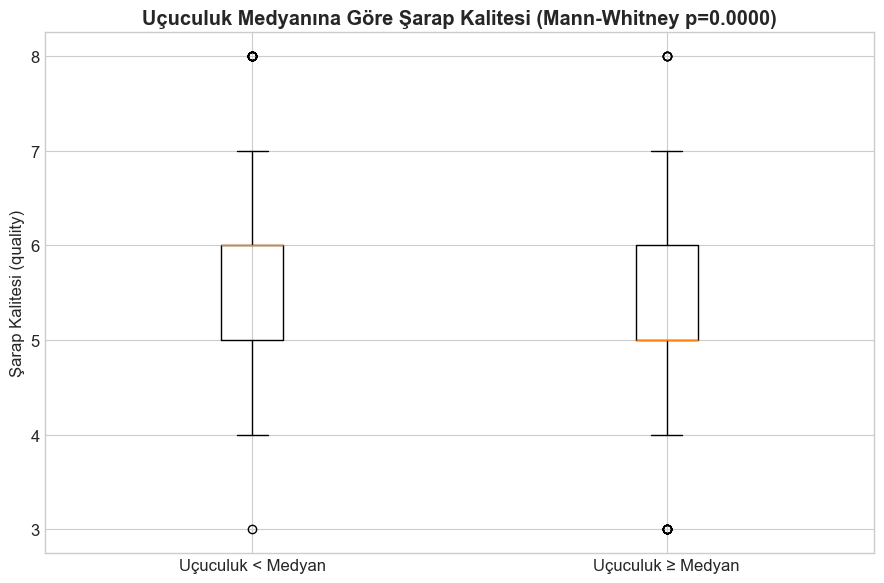

In [13]:
print("\n ===== Egzersiz 1: Şarap Uçuculuğuna Göre Mann Whitney Testi =====")

medyan = wine['volatile acidity'].median()
print(f"\nŞarap uçuculuğunun medyanı: {medyan:.2f}")

medyan_ust = wine[wine['volatile acidity'] >= medyan]['quality']
medyan_alt = wine[wine['volatile acidity'] < medyan]['quality']

# Mann-Whitney U testi
u_stat, p_deger = stats.mannwhitneyu(medyan_ust, medyan_alt, alternative='two-sided')
print(f"Mann-Whitney U istatistiği: {u_stat:.1f}, p-değeri: {p_deger:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot([medyan_alt, medyan_ust], labels=['Uçuculuk < Medyan', 'Uçuculuk ≥ Medyan'])
ax.set_ylabel('Şarap Kalitesi (quality)')
ax.set_title(f'Uçuculuk Medyanına Göre Şarap Kalitesi (Mann-Whitney p={p_deger:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

---

### **E2 (Python).**
`Absenteeism_at_work.csv`'de `Social drinker` (0/1) gruplarına göre
`Absenteeism time in hours` farkını Mann-Whitney ile test et. Önce Shapiro-Wilk ile
normalliği kontrol edip, nonparametrik testin gerekçesini kendi cümlelerinle yaz.

In [14]:
print("\n==== Egzersiz 2: Social Drinker'a Devamsızlık Saatleri Testi ====")

non_drinker = absenteeism[absenteeism['Social smoker'] == 0]['Absenteeism time in hours']
drinker = absenteeism[absenteeism['Social smoker'] == 1]['Absenteeism time in hours']

_ , shapiro_non_drinker = stats.shapiro(non_drinker)
_ , shapiro_drinker = stats.shapiro(drinker)
print(f"Shapiro-Wilk (Non-Drinker): p={shapiro_non_drinker:.6f}")
print(f"Shapiro-Wilk (Drinker): p={shapiro_drinker:.6f}")
if shapiro_non_drinker < 0.05 or shapiro_drinker < 0.05:
    print("En az bir grup normallikten anlamlı şekilde sapıyor - Mann-Whitney uygundur.")
else:
    print("Her iki grup da normal - t-test uygundur.")

# Mann-Whitney U testi
u_stat, p_deger = stats.mannwhitneyu(non_drinker, drinker, alternative='two-sided')
print(f"Mann-Whitney U istatistiği: {u_stat:.1f}, p-değeri: {p_deger:.4f}")
t_stat, p_t = stats.ttest_ind(non_drinker, drinker, equal_var=False)
print(f"Welch t-test istatistiği: {t_stat:.4f}, p-değeri: {p_t:.4f}")


==== Egzersiz 2: Social Drinker'a Devamsızlık Saatleri Testi ====
Shapiro-Wilk (Non-Drinker): p=0.000000
Shapiro-Wilk (Drinker): p=0.000000
En az bir grup normallikten anlamlı şekilde sapıyor - Mann-Whitney uygundur.
Mann-Whitney U istatistiği: 18425.0, p-değeri: 0.9481
Welch t-test istatistiği: 0.3120, p-değeri: 0.7560


---

### **E3 (Python + R).** 
`Absenteeism_at_work.csv`'de `Education` (eğitim seviyesi, 4 kategori)
gruplarına göre `Absenteeism time in hours` karşılaştırmasını Kruskal-Wallis ile **hem
Python'da hem R'da** yap, H-istatistiği ve p-değerinin örtüştüğünü doğrula.

In [15]:
print("\n ==== Egzersiz 3: Eğitim Seviyesine Göre Devamsızlık Saatleri Testi ====")

egitim_seviye = {1: 'High School', 2: 'Graduate', 3: 'Post-Graduate', 4: 'Master and doctor'}

gruplar_egitim = [absenteeism[absenteeism['Education'] == s]['Absenteeism time in hours'].values for s in [1, 2, 3, 4]]
for s, isim in egitim_seviye.items():
    veri = absenteeism[absenteeism['Education'] == s]['Absenteeism time in hours']
    print(f"{isim}: n={len(veri)}, medyan={veri.median():.1f}, ortalama={veri.mean():.2f}, max={veri.max()}")

# Kruskal-Wallis testi
h_ist, p_kw = stats.kruskal(*gruplar_egitim)
print(f"\nKruskal-Wallis: H={h_ist:.4f}, p={p_kw:.4f}")

if p_kw < 0.05:
    print("H0 reddedildi - en az bir eğitim seviyesi diğerlerinden anlamlı şekilde farklı.")
    print("\n--- Post-hoc: İkili Mann-Whitney Karşılaştırmaları (Bonferroni düzeltmeli) ---")
    from itertools import combinations
    ikili_karsilastirmalar = list(combinations([1, 2, 3, 4], 2))
    alpha_orijinal = 0.05
    alpha_duzeltilmis = alpha_orijinal / len(ikili_karsilastirmalar)  # Bonferroni - 05'e onizleme
    print(f"Bonferroni düzeltilmiş α: {alpha_orijinal}/{len(ikili_karsilastirmalar)} = {alpha_duzeltilmis:.4f}")

    for s1, s2 in ikili_karsilastirmalar:
        grup1 = absenteeism[absenteeism['Education'] == s1]['Absenteeism time in hours']
        grup2 = absenteeism[absenteeism['Education'] == s2]['Absenteeism time in hours']
        _, p_ikili = stats.mannwhitneyu(grup1, grup2)
        anlamli = "✓ ANLAMLI (düzeltilmiş eşiğe göre)" if p_ikili < alpha_duzeltilmis else ""
        print(f"{egitim_seviye[s1]} vs {egitim_seviye[s2]}: p={p_ikili:.4f} {anlamli}")
else:
    print("H0 reddedilemedi - eğitim seviyeleri arasında anlamlı fark bulunamadı.")


 ==== Egzersiz 3: Eğitim Seviyesine Göre Devamsızlık Saatleri Testi ====
High School: n=611, medyan=3.0, ortalama=7.19, max=120
Graduate: n=46, medyan=8.0, ortalama=6.39, max=40
Post-Graduate: n=79, medyan=3.0, ortalama=5.27, max=64
Master and doctor: n=4, medyan=5.5, ortalama=5.25, max=8

Kruskal-Wallis: H=2.7655, p=0.4292
H0 reddedilemedi - eğitim seviyeleri arasında anlamlı fark bulunamadı.



	Kruskal-Wallis rank sum test

data:  Absenteeism_time_in_hours by Education
Kruskal-Wallis chi-squared = 2.7655, df = 3, p-value = 0.4292



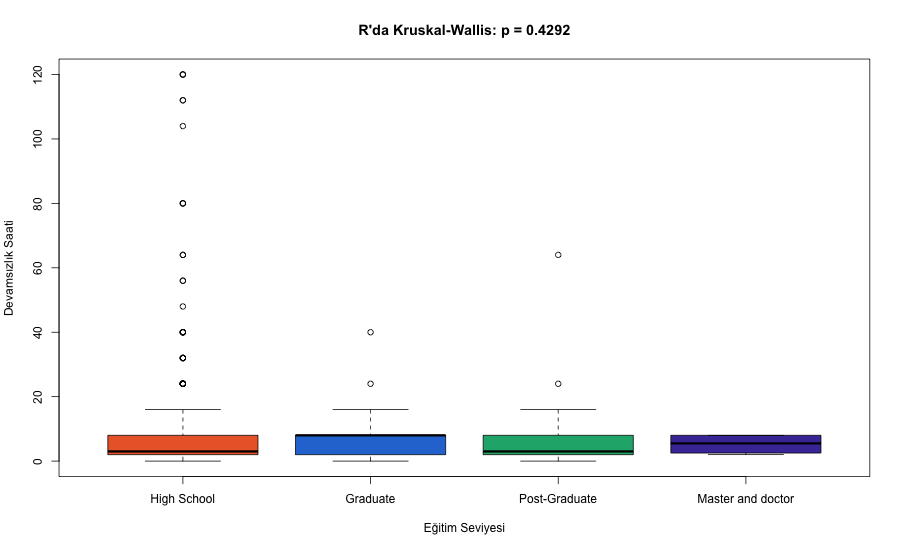

In [16]:
%%R -i absenteeism -w 900 -h 550

colnames(absenteeism) <- gsub(" ", "_", colnames(absenteeism))
absenteeism$Education <- as.factor(absenteeism$Education)

sonuc_kw_egitim <- kruskal.test(Absenteeism_time_in_hours ~ Education, data = absenteeism)
print(sonuc_kw_egitim)

boxplot(Absenteeism_time_in_hours ~ Education, data = absenteeism,
        col = c("#eb6834", "#2a78d6", "#1baf7a", "#4a3aa7"),
        names = c("High School", "Graduate", "Post-Graduate", "Master and doctor"),
        main = paste("R'da Kruskal-Wallis: p =", round(sonuc_kw_egitim$p.value, 4)),
        xlab = "Eğitim Seviyesi", ylab = "Devamsızlık Saati")

---

### **E4 (R).** 
Python 2'deki sentetik senaryoyu genişlet: `n=12` yerine `n=50` ile aynı sentetik
süreci tekrarla (R'da `rexp()` kullanarak) — örneklem büyüklüğü arttıkça Wilcoxon ve
eşleştirilmiş t-test'in p-değerleri birbirine yakınsıyor mu? Neden (ipucu: 02'deki CLT bağlantısı)?

In [17]:
%%R  -w 900 -h 550
set.seed(7)
oncesi <- c(42, 38, 51, 45, 60, 39, 48, 55, 41, 47, 52, 44, 50, 43, 49, 46, 54, 40, 53, 37, 56, 36, 57, 35, 59, 34, 58, 33, 61, 32, 62, 31, 63, 30, 64, 29, 65, 28, 66, 27, 67, 26, 68, 25, 69, 24, 70, 23, 71, 22, 72, 21, 73, 20, 74, 19, 75, 18, 76, 17, 77, 16, 78, 15, 79, 14, 80, 13)
sonrasi <- oncesi - rexp(50, rate = 1/6)

cat("Öncesi:", oncesi)
cat("\nSonrası:", round(sonrasi, 1))

# Geliştirilmiş t-Test ve Wilcoxon testi
t_test_sonuc <- t.test(sonrasi, oncesi, paired = TRUE)
wilcoxon_sonuc <- wilcox.test(sonrasi, oncesi, paired = TRUE)
print(t_test_sonuc)
print(wilcoxon_sonuc)

Öncesi: 42 38 51 45 60 39 48 55 41 47 52 44 50 43 49 46 54 40 53 37 56 36 57 35 59 34 58 33 61 32 62 31 63 30 64 29 65 28 66 27 67 26 68 25 69 24 70 23 71 22 72 21 73 20 74 19 75 18 76 17 77 16 78 15 79 14 80 13
Sonrası: 41.7 28.3 40.7 40.1 56.7 23.3 43.5 29.4 39.8 46.7 46.3 39.5 38.8 31.8 41.7 43.9 49.9 34.3 49.9 31.5 41.6 32.2 54.6 32.4 55.7 32.5 55.3 25.6 50.9 20.7 54.5 26.3 51.5 29.9 60.8 26.7 64.5 26.1 60.4 21.6 62.9 24.5 59.2 24.2 63 20.3 61.4 7.4 67.9 15.5 71.7 11.3 62.7 15.1 70.7 3.3 70.5 -7.6 74.8 16.7 71.3 11.5 66.8 3.8 71.7 11.9 75.9 7.3
	Paired t-test

data:  sonrasi and oncesi
t = -9.7246, df = 67, p-value = 1.963e-14
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -7.526752 -4.963158
sample estimates:
mean difference 
      -6.244955 


	Wilcoxon signed rank test with continuity correction

data:  sonrasi and oncesi
V = 0, p-value = 7.805e-13
alternative hypothesis: true location shift is not equal to 0



In addition: Warning message:
In oncesi - rexp(50, rate = 1/6) :
  longer object length is not a multiple of shorter object length


#### Egzersiz 4 - Açıklama
>Büyük örneklemlerde (\(n=50\) veya \(n=68\)), Merkezi Limit Teoremi sayesinde t-testi çarpıklığa karşı direnç kazanırken, Wilcoxon testi de normal dağılım yaklaşımını kullanmaya başlar. Sonuç olarak, her iki test de evrensel bir normal dağılım paydasında buluştuğu için \(p\)-değerleri birbirine yakınsar ve her iki testin de istatistiksel gücü (asymptotic relative efficiency) maksimuma ulaşır.

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 10 | Hipotez testi temelleri (nonparametrik uzantı) |
| [ISLP (Python)](https://www.statlearning.com) | Ch. 13 | Çoklu test ve dayanıklı (robust) yöntemler |
| [Seeing Theory](https://seeing-theory.brown.edu/frequentist-inference) | Frequentist Inference | İnteraktif |
| [Conover, W.J. — Practical Nonparametric Statistics](https://www.wiley.com/en-us/Practical+Nonparametric+Statistics%2C+3rd+Edition-p-9780471160687) | — | Nonparametrik testlerin klasik referans kitabı |
| [Wine Quality Dataset](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) | Veri | winequality-red.csv kaynağı |
| [Absenteeism at Work Dataset](https://archive.ics.uci.edu/dataset/445/absenteeism+at+work) | Veri | Absenteeism_at_work.csv kaynağı |